# Hyperparameters, GridSearch, and Pipelines
Today we are upgrading our machine learning workflow from manual, repetitive code to professional, automated pipelines. 

**Our Goals for Today:**
1. **The Pipeline Manager (`ColumnTransformer`):** Learn how to route different types of data (text vs. skewed numbers vs. normal numbers) through their own specific transformations automatically.
2. **The Assembly Line (`Pipeline`):** Combine our preprocessing steps and our machine learning model (`ElasticNet`) into a single, leak-proof object.
3. **The Tuning Machines (`RandomizedSearchCV` & `GridSearchCV`):** Stop guessing the best model settings! We will learn how to programmatically test thousands of hyperparameter combinations to find the absolute best model.

**The Business Problem:** 
We are working with the **Abalone Dataset**. Determining the age of an abalone (a type of marine snail) involves cutting the shell, staining it, and counting the number of rings through a microscope—a boring and time-consuming task. We are going to build a machine learning model to predict the number of `Rings` based purely on easy-to-measure physical characteristics (like weight and length)!

**Data Dictionary:**
|Column| Definition |
|------|------------|
|`Sex`|: M (Male), F (Female), I (Infant)|
|`Length`|: Longest shell measurement (mm)|
|`Diameter`|: Perpendicular to length (mm)|
|`Height`|: With meat in shell (mm)|
|`Whole_weight`|: Whole abalone (grams)|
|`Shucked_weight`|: Weight of meat (grams)|
|`Viscera_weight`|: Gut weight after bleeding (grams)|
|`Shell_weight`|: After being dried (grams)|
|`Class` (Target)|: Number of rings. *Note: Age is roughly rings + 1.5 years.*|

In [48]:
# --- Imports ---
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sklearn Tools
import sklearn
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import ElasticNet
from scipy.stats import uniform

# Force sklearn to output DataFrames instead of arrays
sklearn.set_config(transform_output="pandas")

In [49]:
# Fetch Abalone dataset (version 1)
abalone = fetch_openml(name="abalone", version=1, as_frame=True, parser='auto')
df = abalone.frame

# Rename the target column from 'Class' to 'Rings' for clarity
df = df.rename(columns={'Class_number_of_rings': 'Rings'})

# Display the first 5 rows
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [50]:
# Look at the .info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Sex             4177 non-null   category
 1   Length          4177 non-null   float64 
 2   Diameter        4177 non-null   float64 
 3   Height          4177 non-null   float64 
 4   Whole_weight    4177 non-null   float64 
 5   Shucked_weight  4177 non-null   float64 
 6   Viscera_weight  4177 non-null   float64 
 7   Shell_weight    4177 non-null   float64 
 8   Rings           4177 non-null   category
dtypes: category(2), float64(7)
memory usage: 238.1 KB


In [52]:
# Convert Rings to integers
df['Rings'] = df['Rings'].astype('int')

In [53]:
# Look at the summary statistics
df.describe()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [54]:
# Custom Skewness Function
def evaluate_skewness(dataframe):
    numeric_cols = dataframe.select_dtypes(include=np.number).columns
    results = []
    
    for col in numeric_cols:
        skew_val = dataframe[col].skew()
        min_val = dataframe[col].min()
        
        # Determine skew type
        if skew_val > 0.5:
            skew_type = "Right-Skewed"
        elif skew_val < -0.5:
            skew_type = "Left-Skewed"
        else:
            skew_type = "Symmetrical"
            
        # Recommend transformation
        if skew_type == "Symmetrical":
            rec = "None needed"
        elif min_val > 0:
            rec = "Log, Box-Cox or Yeo-Johnson"
        elif min_val == 0:
            rec = "Log or Yeo-Johnson"
        else:
            rec = "Yeo-Johnson" # Yeo-Johnson handles zero and negative numbers!
            
        results.append([col, skew_type, skew_val, rec])
        
    return pd.DataFrame(results, columns=["Feature", "Skewness Type", "Skewness Value", "Recommendation"])

In [55]:
# Checking for Skewness
evaluate_skewness(df)

,Feature,Skewness Type,Skewness Value,Recommendation
0,Length,Left-Skewed,-0.639873,"Log, Box-Cox or Yeo-Johnson"
1,Diameter,Left-Skewed,-0.609198,"Log, Box-Cox or Yeo-Johnson"
2,Height,Right-Skewed,3.128817,Log or Yeo-Johnson
3,Whole_weight,Right-Skewed,0.530959,"Log, Box-Cox or Yeo-Johnson"
4,Shucked_weight,Right-Skewed,0.719098,"Log, Box-Cox or Yeo-Johnson"
5,Viscera_weight,Right-Skewed,0.591852,"Log, Box-Cox or Yeo-Johnson"
6,Shell_weight,Right-Skewed,0.620927,"Log, Box-Cox or Yeo-Johnson"
7,Rings,Right-Skewed,1.114102,"Log, Box-Cox or Yeo-Johnson"


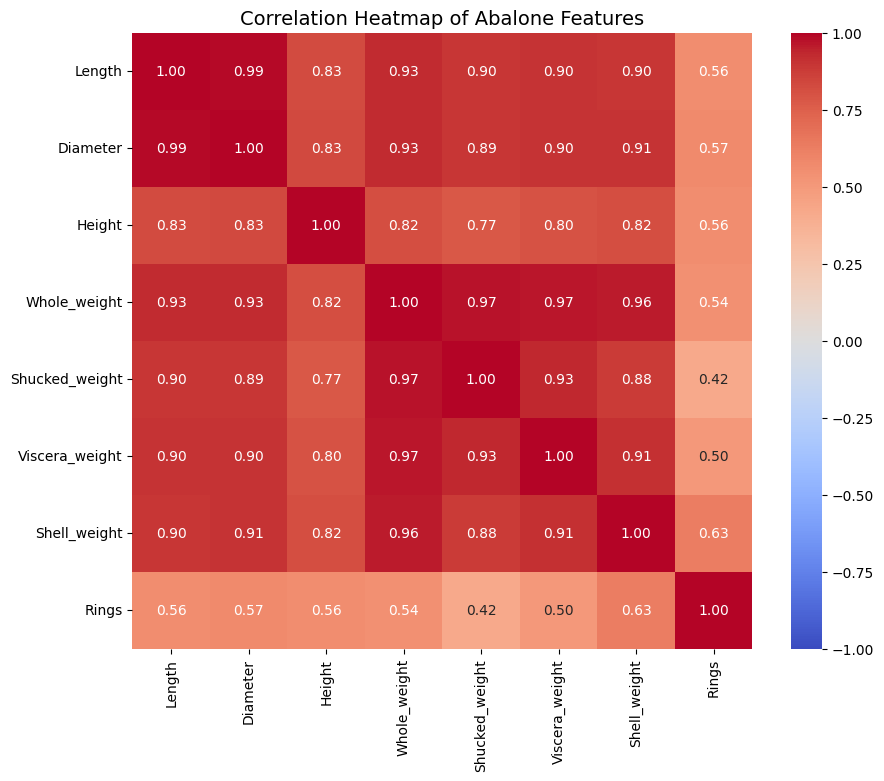

In [57]:
# Look at the correlation
# Setting up the matplotlib figure
plt.figure(figsize=(10, 8))
# Select only the numeric columns for correlation (drops 'Sex')
numeric_cols = df.select_dtypes(include=['float64', 'int64'])
# Generate the heatmap
sns.heatmap(
    numeric_cols.corr(), 
    annot=True,          # Prints the exact correlation numbers
    cmap='coolwarm',     # Blue for negative correlation, Red for positive
    fmt=".2f",           # Rounds numbers to 2 decimal places
    vmin=-1, vmax=1      # Sets the scale from -1 to 1
    ,
)
plt.title("Correlation Heatmap of Abalone Features", fontsize=14)
plt.show()

**What is the heatmap telling us?**
1. **Target Correlation:** `Shell_weight` and `Diameter` have the highest positive correlation with `Rings`.
2. **Multicollinearity Warning:** Look at the bright red squares between all the weight and size features (many are `0.90` or higher!). This means our features are highly correlated with *each other*. Standard Linear Regression struggles with this, which is exactly why using a regularized model like **`ElasticNet`** is the perfect choice for this dataset!

# Train/Test Split

In [58]:
# We will use 'Rings' as our target. We keep 'Sex' this time because we will One-Hot Encode it!
X = df.drop('Rings', axis=1)
y = df['Rings']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=10)

## Part 1: Pipelines
1.1 The "Painful" Way (Manual Preprocessing)
To prepare our data for ElasticNet, we need to apply specific transformations to different columns. If we do this manually, we have to slice our data, fit transformers, and carefully stitch it all back together.

In [59]:
df.columns

Index(['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight',
       'Viscera_weight', 'Shell_weight', 'Rings'],
      dtype='object')

In [60]:
# 1. Define our column groupings
cat_cols = ['Sex']
# All 7 numeric features go directly into the skewed list!
skewed_cols = ['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight',
       'Viscera_weight', 'Shell_weight']

In [61]:
# 2. Categorical: One-Hot Encoding
ohe = OneHotEncoder(drop='first',sparse_output=False)
X_train_cat = ohe.fit_transform(X_train[cat_cols])
X_test_cat = ohe.transform(X_test[cat_cols])

In [62]:
# 3. Numeric Data: Power Transformation
# standardize=False for manual so we can show standard scaling separately
pt = PowerTransformer(standardize=False)
X_train_skew = pt.fit_transform(X_train[skewed_cols])
X_test_skew = pt.transform(X_test[skewed_cols])

In [63]:
# 4. Recombine the data using pd.concat
X_train_recombined = pd.concat([X_train_cat,X_train_skew],axis=1)
X_test_recombined = pd.concat([X_test_cat,X_test_skew],axis=1)

In [64]:
# 5. Apply Standard Scaling across all recombined columns
sc = StandardScaler()
X_train_final = sc.fit_transform(X_train_recombined)
X_test_final = sc.transform(X_test_recombined)

print("Manual Preprocessing Complete. Final Shape:", X_train_final.shape)

Manual Preprocessing Complete. Final Shape: (3341, 9)


In [65]:
# Lets try it on the ElasticNet
en1 = ElasticNet()
en1.fit(X_train_final,y_train)
y_pred_en1 = en1.predict(X_test_final)
print('R2 Score:',r2_score(y_test,y_pred_en1))
print('RMSE:',mean_squared_error(y_test,y_pred_en1)**0.5)

R2 Score: 0.3571675829404777
RMSE: 2.5230690372905524


## 1.2 The Simple Pipeline
A Pipeline chains steps together. However, a basic Pipeline applies every step to every column. If we pass our raw data into a pipeline with a `StandardScaler`, it will crash when it tries to apply math to the text in the Sex column.

__Note:__ What `PowerTransformer` is Actually Doing

The Two-Step Magic of PowerTransformer

When we use `PowerTransformer()` in our pipeline, it actually performs two operations completely automatically, in this specific order:
- __Transformation First:__ It mathematically transforms the data (using Yeo-Johnson by default) to fix the skewness and make the distribution more Gaussian (bell-shaped).
- __Standardization Second:__ Immediately after transforming, it automatically applies standard scaling to the new values (forcing the mean to 0 and variance to 1).

Because it standardizes the data for us under the hood, we do not need to add an extra StandardScaler() step to that specific branch of our pipeline!

In [67]:
# This simple pipeline only works if we feed it strictly numeric data!
simple_numeric_pipe = Pipeline(
    steps=[
        ('ptransform',PowerTransformer()),
        ('model',ElasticNet())
    ]
)

# Test it on just the normal numeric columns
simple_numeric_pipe.fit(X_train[skewed_cols], y_train)
y_pred_pipe = simple_numeric_pipe.predict(X_test[skewed_cols])

print('R2 Score:',r2_score(y_test,y_pred_pipe))
print('RMSE:',mean_squared_error(y_test,y_pred_pipe)**0.5)

R2 Score: 0.3495070809342359
RMSE: 2.538057962547628


## 1.3 The Pipeline Manager `ColumnTransformer`
To fix the mixed-data problem, we use a `ColumnTransformer`. It acts as a factory manager, routing specific columns to specific pipelines, and stitching them together automatically.

In [68]:
# Branch 1: Categorical Encoding
cat_pipe = Pipeline(
    steps=[
        ('ohe',OneHotEncoder(drop='first',sparse_output=False))
    ]
)

In [70]:
# Branch 2: Power Transformation (Fixes skewness, PT standardizes by default!)
skew_pipe = Pipeline(
    steps=[
        ('pt',PowerTransformer())
    ]
)

In [71]:
# The Factory Manager
preprocessor = ColumnTransformer(
    transformers=[
        ('cat',cat_pipe,cat_cols), # This is for One Hot Encoder
        ('skew',skew_pipe,skewed_cols) # This is for Power Transformer
    ], remainder='drop'
)

In [73]:
# The Main Pipeline (Preprocessor + Model)
main_pipe = Pipeline(
    steps = [
        ('preprocessor',preprocessor),
        ('model',ElasticNet())
    ]
)

# We can fit the entire dataset at once now!
main_pipe.fit(X_train,y_train)
y_pre_main_pipe = main_pipe.predict(X_test)

print('R2 Score:',r2_score(y_test,y_pre_main_pipe))
print('RMSE:',mean_squared_error(y_test,y_pre_main_pipe)**0.5)

R2 Score: 0.34950710093625925
RMSE: 2.5380579235262233


# Part 2: Hyperparameter Tuning
Now that we have an automated master_pipe, we need to find the best hyperparameters for `ElasticNet`. ElasticNet requires us to balance two parameters:
- __alpha:__ The overall strength of the penalty.
- __l1_ratio:__ The mix between L1 (Lasso) and L2 (Ridge).

## 2.1 Exploring the Map: RandomizedSearchCV
When searching a massive parameter space (like alpha ranging from 0.001 to 100), checking every single combination takes too long. RandomizedSearchCV samples random combinations to quickly find the "good neighborhoods" of parameters.

In [78]:
# 1. Define a broad distribution of parameters to search
param_distributions = {
    'model__alpha': np.logspace(-3,1,100),
    'model__l1_ratio':uniform(0,1)
}

In [79]:
# 2. Setup the RandomizedSearchCV
rs = RandomizedSearchCV(
    estimator = main_pipe,  # Main Pipe
    param_distributions= param_distributions, # Parameter to search
    n_iter = 30,
    cv = 5,
    scoring='r2',
    random_state = 42,
    # n_jobs = -1
    
)

In [80]:
# 3. Fit the search
rs.fit(X_train,y_train)

print("--- Randomized Search Results ---")
print(f"Best Parameters: {rs.best_params_}")
print(f"Best CV R2 Score: {rs.best_score_:.4f}")

--- Randomized Search Results ---
Best Parameters: {'model__alpha': np.float64(0.0012045035402587824), 'model__l1_ratio': np.float64(0.8599404067363206)}
Best CV R2 Score: 0.5419


In [81]:
# How to get the best model that includes the best parameters that RandomizedSearchCV found?
rs.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Sex','Length','Diameter',...,'Shucked_weight','Viscera_weight', 'Shell_weight']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('skew', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset o

In [85]:
# How to look at the results of the RandomizedSearchCV's Cross Validation
pd.DataFrame(rs.cv_results_).sort_values('rank_test_score').head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,param_model__l1_ratio,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
17,0.230492,0.029085,0.015027,0.001870,0.001205,0.859940,"{'model__alpha': 0.0012045035402587824, 'model...",0.527117,0.546567,0.584481,0.525719,0.525837,0.541944,0.022686,1
6,0.208757,0.013490,0.014063,0.001225,0.001097,0.721999,"{'model__alpha': 0.0010974987654930556, 'model...",0.527478,0.546505,0.584339,0.525191,0.526025,0.541908,0.022634,2
22,0.233867,0.023402,0.014733,0.002067,0.001097,0.684233,"{'model__alpha': 0.0010974987654930556, 'model...",0.527597,0.546482,0.584287,0.525008,0.526101,0.541895,0.022615,3
27,0.216968,0.008296,0.014005,0.000444,0.001097,0.425156,"{'model__alpha': 0.0010974987654930556, 'model...",0.528294,0.546302,0.583927,0.523772,0.526546,0.541768,0.022517,4
5,0.217636,0.009024,0.014083,0.000581,0.001205,0.020584,"{'model__alpha': 0.0012045035402587824, 'model...",0.529227,0.545840,0.583199,0.521420,0.527188,0.541375,0.022433,5


## 2.2 Pinpointing the Target: GridSearchCV
Now that RandomizedSearchCV showed us roughly where the best parameters live (e.g., perhaps an alpha near 0.001 and an l1_ratio near 0.859), we can use GridSearchCV to exhaustively test an exact grid of values around that neighborhood to find the absolute maximum performance.

In [86]:
# 1. Define a highly specific, narrow grid based on the RandomizedSearchCV results
# (Assuming RandomSearch found alpha ~ 0.001 and l1_ratio ~ 0.85)
param_grid = {
    'model__alpha':[0.0009,0.0015,0.002],
    'model__l1_ratio': [0.8,0.85,0.9]
}

In [88]:
# 2. Setup the GridSearchCV
gs = GridSearchCV(
    estimator= main_pipe,
    param_grid= param_grid,
    cv=5,
    scoring='r2'
)

In [89]:
# 3. Fit the grid
gs.fit(X_train,y_train)

print("--- Grid Search Results ---")
print(f"Absolute Best Parameters: {gs.best_params_}")
print(f"Absolute Best CV R2 Score: {gs.best_score_}")

# Evaluate the ultimate winning model on the unseen test set
final_model = gs.best_estimator_
print(f"\nFinal Test R2: {final_model.score(X_test, y_test):.4f}")

--- Grid Search Results ---
Absolute Best Parameters: {'model__alpha': 0.0015, 'model__l1_ratio': 0.9}
Absolute Best CV R2 Score: 0.5419605515352623

Final Test R2: 0.5547


__Conclusion__
By combining ColumnTransformer, Pipeline, and GridSearchCV, you have successfully built a professional, leak-proof machine learning workflow!
- Manual Preprocessing is great for understanding the mechanics of your data, but it is highly prone to human error, index mismatches, and data leakage.
- Pipelines act as an automated factory line. They ensure that the exact same transformations learned from the training data are flawlessly applied to the unseen test data.
- Hyperparameter Tuning (RandomizedSearchCV and GridSearchCV) takes the manual guesswork out of modeling. Instead of blindly guessing the best settings, we can programmatically scan the parameter space to guarantee we deploy the best possible model.